# STUDENTS PLACEMENT PROJECT BY USING MACHINE LEARNING

ENVIRONMENT SETUP AND INITIAL DATA LOADING WITH PANDAS

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [ ]:
# Load dataset 
df = pd.read_csv("collegePlace_Complete.csv")
df.head()

,Age,Gender,Stream,Internships,CGPA,Hostel,HistoryOfBacklogs,PlacedOrNot,placement_exam_marks
0,22,Male,Electronics And Communication,1,8,1,1,1,26.0
1,21,Female,Computer Science,0,7,1,1,1,38.0
2,22,Female,Information Technology,1,6,0,0,1,40.0
3,21,Male,Information Technology,0,8,0,1,1,8.0
4,22,Male,Mechanical,0,8,1,0,1,17.0


In [4]:
df.sample(10)

,Age,Gender,Stream,Internships,CGPA,Hostel,HistoryOfBacklogs,PlacedOrNot,placement_exam_marks
2619,21,Male,Civil,0,7,0,0,0,28.0
378,21,Male,Mechanical,1,6,1,1,0,25.0
277,21,Female,Civil,1,7,1,0,0,15.0
2063,21,Male,Electrical,1,8,0,0,1,28.0
127,24,Male,Computer Science,2,7,0,0,1,23.0
2826,21,Male,Mechanical,1,8,1,0,1,28.0
1553,22,Male,Computer Science,0,7,0,0,0,28.0
170,21,Male,Civil,1,6,0,0,1,37.0
1031,22,Male,Computer Science,2,7,0,0,1,28.0
828,21,Male,Electronics And Communication,2,6,0,0,1,63.0


Exploratory Data Analysis With Pandas

In [ ]:

df.describe()

,Age,Internships,CGPA,Hostel,HistoryOfBacklogs,PlacedOrNot,placement_exam_marks
count,2966.000000,2966.000000,2966.000000,2966.000000,2966.000000,2966.000000,2966.000000
mean,21.485840,0.703641,7.073837,0.269049,0.192178,0.552596,29.424477
std,1.324933,0.740197,0.967748,0.443540,0.394079,0.497310,11.282881
min,19.000000,0.000000,5.000000,0.000000,0.000000,0.000000,0.000000
25%,21.000000,0.000000,6.000000,0.000000,0.000000,0.000000,28.000000
50%,21.000000,1.000000,7.000000,0.000000,0.000000,1.000000,28.000000
75%,22.000000,1.000000,8.000000,1.000000,0.000000,1.000000,28.000000
max,30.000000,3.000000,9.000000,1.000000,1.000000,1.000000,100.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2966 entries, 0 to 2965
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   2966 non-null   int64  
 1   Gender                2966 non-null   object 
 2   Stream                2966 non-null   object 
 3   Internships           2966 non-null   int64  
 4   CGPA                  2966 non-null   int64  
 5   Hostel                2966 non-null   int64  
 6   HistoryOfBacklogs     2966 non-null   int64  
 7   PlacedOrNot           2966 non-null   int64  
 8   placement_exam_marks  2966 non-null   float64
dtypes: float64(1), int64(6), object(2)
memory usage: 208.7+ KB


In [7]:
df.shape

(2966, 9)

In [8]:
df.isnull().sum()

Age                     0
Gender                  0
Stream                  0
Internships             0
CGPA                    0
Hostel                  0
HistoryOfBacklogs       0
PlacedOrNot             0
placement_exam_marks    0
dtype: int64

In [9]:
df.columns

Index(['Age', 'Gender', 'Stream', 'Internships', 'CGPA', 'Hostel',
       'HistoryOfBacklogs', 'PlacedOrNot', 'placement_exam_marks'],
      dtype='object')

ENCODING CATEGORIAL VARIBLES USING PANDAS

In [11]:
df['Gender'].replace({'Male':0, 'Female': 1}, inplace=True)
df.head()

,Age,Gender,Stream,Internships,CGPA,Hostel,HistoryOfBacklogs,PlacedOrNot,placement_exam_marks
0,22,0,Electronics And Communication,1,8,1,1,1,26.0
1,21,1,Computer Science,0,7,1,1,1,38.0
2,22,1,Information Technology,1,6,0,0,1,40.0
3,21,0,Information Technology,0,8,0,1,1,8.0
4,22,0,Mechanical,0,8,1,0,1,17.0


In [12]:
df['Stream'].unique()

array(['Electronics And Communication', 'Computer Science',
       'Information Technology', 'Mechanical', 'Electrical', 'Civil'],
      dtype=object)

In [14]:
df['Stream'].replace({'Electronics And Communication':'0','Computer Science':'1','Information Technology':'2','Mechanical':'3','Electrical':'4','Civil':'5'},inplace=True)
df.head()

,Age,Gender,Stream,Internships,CGPA,Hostel,HistoryOfBacklogs,PlacedOrNot,placement_exam_marks
0,22,0,0,1,8,1,1,1,26.0
1,21,1,1,0,7,1,1,1,38.0
2,22,1,2,1,6,0,0,1,40.0
3,21,0,2,0,8,0,1,1,8.0
4,22,0,3,0,8,1,0,1,17.0


In [20]:
print("Mean value of cgpa",df['CGPA'].mean())
print("Std value of cgpa",df['CGPA'].std())
print("Min value of cgpa",df['CGPA'].min())
print("Max value of cgpa",df['CGPA'].max())

Mean value of cgpa 7.073836817262306
Std value of cgpa 0.9677479876645856
Min value of cgpa 5
Max value of cgpa 9


In [21]:
# Finding the boundary values
print("Highest allowed",df['CGPA'].mean() + 3*df['CGPA'].std())
print("Lowest allowed",df['CGPA'].mean() - 3*df['CGPA'].std())

Highest allowed 9.977080780256063
Lowest allowed 4.170592854268549


In [22]:
age=df['Age']
stream=df['Stream']
internship=df['Internships']
cgpa=df['CGPA']
hostel=df['Hostel']
backlog=df['HistoryOfBacklogs']
placement_marks=df['placement_exam_marks']
Y=df['PlacedOrNot']

Data visualization

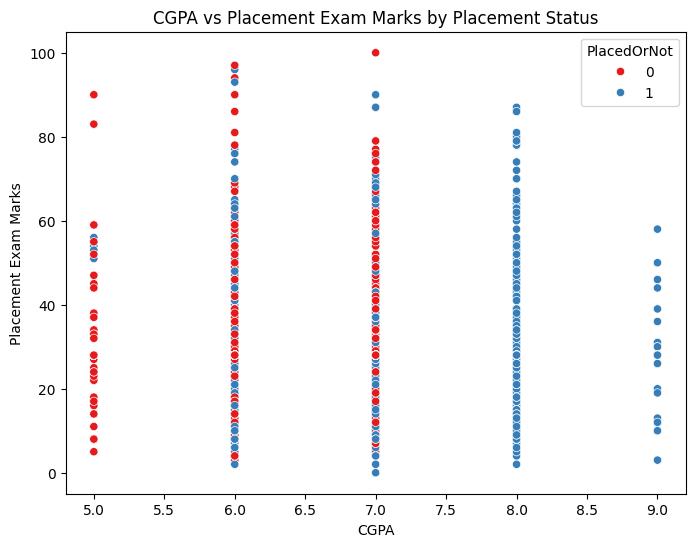

In [23]:

plt.figure(figsize=(8, 6))

# Create the scatter plot using seaborn
sns.scatterplot(data=df, x='CGPA', y='placement_exam_marks', hue='PlacedOrNot', palette='Set1')

# Add titles and labels
plt.title('CGPA vs Placement Exam Marks by Placement Status')
plt.xlabel('CGPA')
plt.ylabel('Placement Exam Marks')

# Display the plot
plt.show()

C:\Users\AMIT KUMAR\AppData\Local\Temp\ipykernel_29592\3062856204.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='PlacedOrNot', palette='viridis')


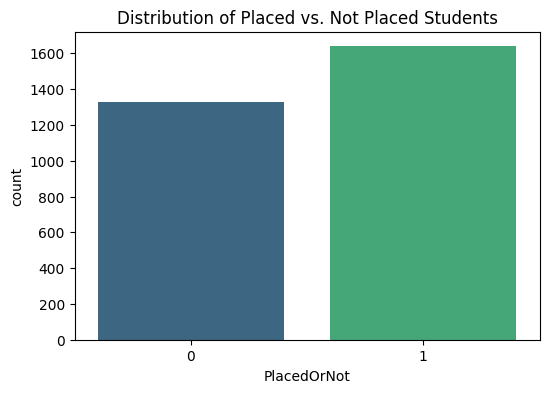

In [32]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='PlacedOrNot', palette='viridis')
plt.title('Distribution of Placed vs. Not Placed Students')
plt.show()

In [24]:
y = df['PlacedOrNot']
X = df.drop(['PlacedOrNot'],axis=1)

In [25]:
X

,Age,Gender,Stream,Internships,CGPA,Hostel,HistoryOfBacklogs,placement_exam_marks
0,22,0,0,1,8,1,1,26.0
1,21,1,1,0,7,1,1,38.0
2,22,1,2,1,6,0,0,40.0
3,21,0,2,0,8,0,1,8.0
4,22,0,3,0,8,1,0,17.0
...,...,...,...,...,...,...,...,...
2961,23,0,2,0,7,0,0,28.0
2962,23,0,3,1,7,1,0,28.0
2963,22,0,2,1,7,0,0,28.0
2964,22,0,1,1,7,0,0,28.0


DATA PREPROCESSING AND XGBOOST MODEL INITIALIZATION

In [28]:
X_train , X_test, y_train, y_test = train_test_split(X,y, test_size=0.1)

In [29]:
from xgboost import XGBClassifier

In [33]:
clf = XGBClassifier(learning_rate=0.09,n_estimators=150, eval_metric='logloss')


ONE-HOT ENCODING , MODEL FITTING , AND GENERATING PREDICTIONS

In [36]:


# Convert text columns to numerical one-hot encoded columns
X_train = pd.get_dummies(X_train)

X_test = pd.get_dummies(X_test) 

# Now fit the model
clf.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [38]:
predictions = clf.predict(X_test)
predictions

array([0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1,
       1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1,
       1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0,
       0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1,
       1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1,
       1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0,
       0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1])

EVALUATING MODEL PERFORMANCE : 
CALCULATING ACCURACY SCORE WITH SCIKIT LEARN

In [41]:
from sklearn.metrics import confusion_matrix , precision_score , recall_score , f1_score, accuracy_score
accuracy =accuracy_score(y_test,predictions)

In [42]:
accuracy

0.9124579124579124

PROJECT COMPLETED